# How to use the temporal logic ?
First import maboss and the temporal_logic module

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
#from IPython.display import display

# this is needed only if maboss is not seen by Jupyter
path_dev = os.path.expanduser("~/Documents/MaBoSS/pyMaBoSS")
if path_dev not in sys.path:
    sys.path.insert(0, path_dev)

from maboss import temporal_logic as tl

# About using AI for querying
**It is highly recommended to use the following prompt to ensure the respect of the grammar.**
### **!! AI is still making mistakes, review the results of the prompt carefully before using them !!**

Role: You are an expert compiler for the MaBoSS temporal_logic module. Your task is to translate biological assertions into Formula objects using a strict textual syntax.

1. THE VALIDATION REGEX (Mandatory):
Every query must strictly match this REGEX:
`^(Pmax|Pmin|P|T|Tmin|Tmax|D|M|Inc|Dec)\((node|state|fp)\:(.+?)\)(?:\s*(<=|>=|<|>|=|==|!=|/)\s*(0(?:\.\d+)?|1(?:\.0+)?|\?|))?(?:\s*\[(.*?)\])?(?:\s*\[(.*?)\])?(?:\s*\[(.*?)\])?`

2. MODEL & COMPARISON RULES:

    Model Isolation: Each query applies to a specific model (e.g., Colorectal or Melanoma). If a sentence compares two models, generate two separate queries and specify which model each belongs to.

    compare: Scope: The compare:MUTATION option is used only to compare two mutational states within the same model. It cannot compare different model types.

3. SYNTAX RULES (Based on formulas.py):

    Spacing: One space on each side of the slash /. One space between each set of brackets ] [.

    The 3 Blocks: Structure must be [ LOGIC ] [ MUTATIONS ] [ OPTIONS ].

    Mutations & Options: Use SPACES only as separators. Commas are strictly forbidden inside brackets.

        Unique Exception: Commas are allowed only to list targets node:A,B or comparison references compare:M1,M2.

    Values:

        ? is reserved exclusively for the P type with the = operator.

        Probabilities must be between 0 and 1.

        Inc and Dec must use the slash / if no threshold value is provided.

4. REFERENCE EXAMPLES (Do NOT rewrite these in your output):

    Simple Inhibition: Inc(node:EGFR) / [ ] [ BRAF:OFF ] [ 5% ]

    Probability Request: P(node:ERK) = ? [ ERK & AKT ] [ ] [ ]

    Synergy on a Model: Dec(node:ERK) / [ ] [ BRAF:OFF MEK:OFF ] [ compare:BRAF:OFF ]

OUTPUT INSTRUCTIONS:

    Identify the required model(s).

    Generate the query/queries in the following format: Model [Name]: QUERY.

    Do not rewrite the examples provided above.

    Provide only the final code/result without any additional commentary.

# Introduction
Through this notebook, we are going to try to answer all this assertions

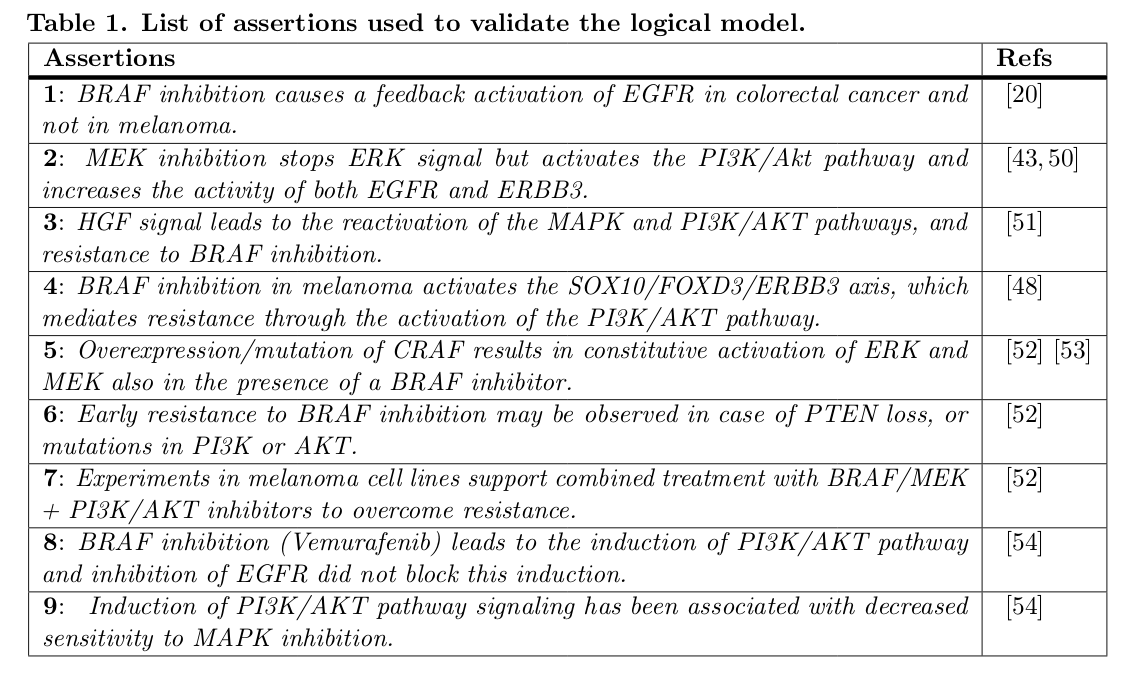

In [2]:
from IPython.display import Image
Image("assertion_table.png")

In [3]:
assertions_list_melanoma = [] #doing a list so only one thing to pass in the function, easier and cleaner
assertions_list_colorectal = []
assertions_list_no_i_s = []
assertions_list_strong_EGF = []

file_bnd = "BRAF_Model.bnd"
file_cfg = "BRAF_Model.cfg"

#the list of dictionaries for the initial states, we are going to work on 3 models, two with the initial states below, the third without one.
i_s_colorectal = [{'node':'SOX10', 'istate': [1,0]}, {'node': 'BRAF' , 'istate': [0,1]}]
i_s_melanoma = [{'node':'SOX10', 'istate': [0,1]}, {'node': 'BRAF' , 'istate': [0,1]}]
i_s_strong_EGF = [{'node':'EGF', 'istate': [0,1]}]

BRAF_inhibition = 'BRAF:OFF'
MEK_inhibition = 'MEK_b1:OFF MEK_b2:OFF'
BRAF_EGFR_inhibition = 'BRAF:OFF EGFR:OFF'
BRAF_MEK_PI3K_inhibition = 'BRAF:OFF MEK_b1:OFF MEK_b2:OFF PI3K:OFF'

First thing first, transform those sentences in queries the program can read and treat :

# Assertion 1
*BRAF inhibition causes a feedback activation of EGFR in colorectal cancer and not in melanoma.*

This assertion is running two models :
- one for the colorectal cancer
- the other for the melanoma

But, only one assertion is needed. The waited result is not the same though.
For the colorectal model we are waiting a **True**.
For the melanoma model we are waiting a **False**.
Note that if you have a difference of 0 for one or both of them, you can change the number of digits after the dot by passing an option : `digits:int` in the last brackets.

In [4]:
assertion_1 = f"Inc(node:EGFR) / [ ] [ BRAF:OFF ] [ 5% digits:3 ]" #sensibility of 3 digits after dot and minimum 5% of change
assertions_list_colorectal.append(assertion_1)
assertions_list_melanoma.append(assertion_1)

# Assertion 2
*MEK inhibition stops ERK signal but activates the PI3K/Akt pathway and increases the activity of both EGFR and ERBB3.*
This assertion will be run on both models. Both of them wait the same result.
But it needs several sentences that will return to you three dataframes accordingly.
- **For ERK signal stopped** : "Dec(node:ERK) / [ ] [ MEK:OFF ] [ 5% ]" -> here the stop signal is translate as a decrease.
- **For PI3K/AKT pathway activated** : "Inc(node:PI3K,AKT) / [ ] [ MEK:OFF ] [ 5% ]" -> note that more than one name can be passed if they both have the same evolution direction
- **For EGFR and ERBB3 augmented** : "Inc(node:EGFR,ERBB3) / [ ] [ MEK:OFF ] [ 5% ]"

### Why not pass the last two in one ?
Because if you do so, it will return the combination of the **four** nodes active at the same time. But you are only interested in combination of 2.
But if you want the activation of the four, you can do it like that : `Inc(node:PI3K,AKT,EGFR,ERBB3) / ...`


In [5]:
assertion_2_a = f"Dec(node:ERK_b1,ERK_b2) / [ ] [ {MEK_inhibition} ] [ 5% digits:3 ]"
assertion_2_b = f"Inc(node:PI3K,AKT) / [ ] [ {MEK_inhibition} ] [ 5% digits:3 ]"
assertion_2_c = f"Inc(node:EGFR,ERBB3) / [ ] [ {MEK_inhibition} ] [ 5% digits:3 ]"
assertions_list_no_i_s.append(assertion_2_a)
assertions_list_no_i_s.append(assertion_2_b)
assertions_list_no_i_s.append(assertion_2_c)

# Assertion 3
*HGF signal leads to the reactivation of the MAPK and PI3K/AKT pathways, and resistance to BRAF inhibition.*

For this assertion, we are not going to compare the mutation with the master simulation but with another mutation.
In the options brackets (where the 5% is), add the option *compare* to it just like below. The program will kow it has to compare with the results of BRAF:OFF mutation.

In [6]:
assertion_3_a = "Inc(node:ERK_b1) / [ ] [ BRAF:OFF HGF:ON ] [ 5% compare:BRAF:OFF digits:3 ]" #resistance to BRAF inhibition (same node evaluation as in MaBoSS_test)
assertion_3_b = "Inc(node:PI3K,AKT) / [ ] [ BRAF:OFF HGF:ON ] [ 5% compare:BRAF:OFF digits:3 ]"
assertions_list_no_i_s.append(assertion_3_a)
assertions_list_no_i_s.append(assertion_3_b)

# Assertion 4
*BRAF inhibition in melanoma activates the SOX10/FOXD3/ERBB3 axis, which mediates resistance through the activation of the PI3K/AKT pathway.*

In [7]:
assertion_4_a = "Inc(node:SOX10,FOXD3,ERBB3) / [ ] [ BRAF:OFF ] [ 5% digits:3 ]"
assertion_4_b = "Inc(node:PI3K,AKT,ERBB3) / [ ] [ BRAF:OFF ] [ 5% digits:3 ]" #added ERBB3 like in maboss_test
#In two assertions like in maboss test and a third for the two in one to see difference
assertion_4_c = "Dec(node:Proliferation_b1) / [ ] [ BRAF:OFF SOX10:OFF ] [ 5% digits:3 ]"
assertion_4_d = "Dec(node:Proliferation_b2) / [ ] [ BRAF:OFF SOX10:OFF ] [ 5% digits:3 ]"
assertion_4_e = "Dec(node:Proliferation_b1,Proliferation_b2) / [ ] [ BRAF:OFF SOX10:OFF ] [ 5% digits:3 ]"
assertions_list_melanoma.append(assertion_4_a)
assertions_list_melanoma.append(assertion_4_b)
assertions_list_melanoma.append(assertion_4_c)
assertions_list_melanoma.append(assertion_4_d)
assertions_list_melanoma.append(assertion_4_e)

# Assertion 5
*Overexpression/mutation of CRAF results in constitutive activation of ERK and MEK also in the presence of a BRAF inhibitor.*

In [8]:
assertion_5_a = "Inc(node:ERK_b1,MEK_b1) / [ ] [ CRAF:ON BRAF:OFF ] [ 5% digits:3 ]"
assertion_5_b = "Inc(node:ERK_b1,MEK_b1) / [ ] [ CRAF:ON ] [ 5% digits:3 ]" #without BRAF inhibitor
assertion_5_c = "Inc(node:ERK_b1,MEK_b1) / [ ] [ CRAF:ON ] [ 5% compare:BRAF:OFF,CRAF:ON digits:3 ]" #comparison of the two ? supposed to be similar
assertions_list_no_i_s.append(assertion_5_a)
assertions_list_no_i_s.append(assertion_5_b)
assertions_list_no_i_s.append(assertion_5_c)

# Assertion 6
*Early resistance to BRAF inhibition may be observed in case of PTEN loss, or mutations in PI3K or AKT.*

In [9]:
# PTEN loss increase of proliferation
assertion_6_a = "Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ BRAF:OFF PTEN:OFF ] [ transient:start:0.05,end:0.1,optimum:0.5 digits:3 ]"
# Mutation of PI3K or AKT
assertion_6_b = "Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ BRAF:OFF PI3K:ON ] [ transient:start:0.05,end:0.1,optimum:0.5 digits:3 ]"
assertion_6_c = "Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ BRAF:OFF AKT:ON ] [ transient:start:0.05,end:0.1,optimum:0.5 digits:3 ]"
assertions_list_no_i_s.append(assertion_6_a)
assertions_list_no_i_s.append(assertion_6_b)
assertions_list_no_i_s.append(assertion_6_c)

# Assertion 7
*Experiments in melanoma cell lines support combined treatment with BRAF/MEK + PI3K/AKT inhibitors to overcome resistance.*

In [10]:
assertion_7 = "Dec(node:Proliferation_b1,Proliferation_b2) / [ ] [ BRAF:OFF MEK_b1:OFF MEK_b2:OFF PI3K:OFF AKT:OFF ] [ 5% compare:BRAF:OFF,MEK_b1:OFF,MEK_b2:OFF,PI3K:OFF digits:3 ]"
assertions_list_no_i_s.append(assertion_7)

# Assertion 8
*BRAF inhibition (Vemurafenib) leads to the induction of PI3K/AKT pathway and inhibition of EGFR did not block this induction.*

In [11]:
assertion_8_a = "Inc(node:PI3K,AKT) / [ ] [ BRAF:OFF ] [ 5% digits:2 ]"
assertion_8_b = f"Inc(node:PI3K,AKT) / [ ] [ {BRAF_EGFR_inhibition} ] [ 5% digits:3 ]"
assertion_8_c = "Inc(node:PI3K,AKT) / [ ] [ BRAF:OFF ] [ compare:BRAF:OFF,EGFR:OFF digits:3 ]"
assertion_8_d = f"Inc(node:PI3K,AKT) / [ ] [ {BRAF_EGFR_inhibition} ] [ compare:BRAF:OFF digits:3 ]"
assertions_list_no_i_s.append(assertion_8_a)
assertions_list_no_i_s.append(assertion_8_b)
assertions_list_no_i_s.append(assertion_8_c)
assertions_list_no_i_s.append(assertion_8_d)
# maboss_test also compared this : 'the inhibition of both EGFR and BRAF when the EGF signal is strong is better than just BRAF inhibition', compared on an other initial state
assertion_8_e = f"Dec(node:Proliferation_b1) / [ ] [ {BRAF_EGFR_inhibition} ] [ compare:BRAF:OFF digits:3 ]"
assertions_list_strong_EGF.append(assertion_8_e)

# Assertion 9
*Induction of PI3K/AKT pathway signaling has been associated with decreased sensitivity to MAPK inhibition.*

In [12]:
assertion_9 = "Inc(node:Proliferation_b1,Proliferation_b2) / [ ] [ PI3K:ON AKT:ON ] [ compare:PI3K:OFF,AKT:OFF digits:3 ]"
assertions_list_no_i_s.append(assertion_9)

# Evaluations

In [13]:
results_colorectal = tl.MaBoSSEvaluator.querying(assertions_list_colorectal, file_cfg, file_bnd, i_s_colorectal)
results_melanoma = tl.MaBoSSEvaluator.querying(assertions_list_melanoma, file_cfg, file_bnd, i_s_melanoma)
results_no_is = tl.MaBoSSEvaluator.querying(assertions_list_no_i_s, file_cfg, file_bnd)
results_strong_EGF = tl.MaBoSSEvaluator.querying(assertions_list_strong_EGF, file_cfg, file_bnd, i_s_strong_EGF)

Evaluations done !
Evaluations done !
Evaluations done !
Evaluations done !


# Display the results

In [14]:
viz_no_is = tl.visualiser.Visualiser(list_queries=assertions_list_no_i_s,list_of_results=results_no_is)
viz_melanoma = tl.visualiser.Visualiser(list_queries=assertions_list_melanoma,list_of_results=results_melanoma)
viz_colorectal = tl.visualiser.Visualiser(list_queries=assertions_list_colorectal,list_of_results=results_colorectal)
viz_strong_EGF = tl.visualiser.Visualiser(list_queries=assertions_list_strong_EGF,list_of_results=results_strong_EGF)
viz_no_is.display_results_and_queries("No initial state") #title is optional
viz_colorectal.display_results_and_queries("Colorectal Cancer")
viz_melanoma.display_results_and_queries("Melanoma")
viz_strong_EGF.display_results_and_queries("EGF strong")

No initial state
Query 1 : Dec(node:ERK_b1,ERK_b2) / [ ] [ MEK_b1:OFF MEK_b2:OFF ] [ 5% digits:3 ]


,ERK_b1 from master,ERK_b1 from mutation,Difference ERK_b1,Percentage ERK_b1,Decrease ERK_b1,ERK_b2 from master,ERK_b2 from mutation,Difference ERK_b2,Percentage ERK_b2,Decrease ERK_b2
0,0.476,0.0,-0.476,-100.00%,True,0.157,0.0,-0.157,-100.00%,True


Query 2 : Inc(node:PI3K,AKT) / [ ] [ MEK_b1:OFF MEK_b2:OFF ] [ 5% digits:3 ]


,PI3K from master,PI3K from mutation,Difference PI3K,Percentage PI3K,Increase PI3K,AKT from master,AKT from mutation,Difference AKT,Percentage AKT,Increase AKT
0,0.356,0.475,0.119,33.43%,True,0.354,0.475,0.121,34.18%,True


Query 3 : Inc(node:EGFR,ERBB3) / [ ] [ MEK_b1:OFF MEK_b2:OFF ] [ 5% digits:3 ]


...

,Proliferation_b2 from master,Proliferation_b2 from mutation,Difference Proliferation_b2,Percentage Proliferation_b2,Decrease Proliferation_b2
0,0.146,0.127,-0.019,-13.01%,True


Query 6 : Dec(node:Proliferation_b1,Proliferation_b2) / [ ] [ BRAF:OFF SOX10:OFF ] [ 5% digits:3 ]


,Proliferation_b1 from master,Proliferation_b1 from mutation,Difference Proliferation_b1,Percentage Proliferation_b1,Decrease Proliferation_b1,Proliferation_b2 from master,Proliferation_b2 from mutation,Difference Proliferation_b2,Percentage Proliferation_b2,Decrease Proliferation_b2
0,0.243,0.208,-0.035,-14.40%,True,0.146,0.127,-0.019,-13.01%,True


EGF strong
Query 1 : Dec(node:Proliferation_b1) / [ ] [ BRAF:OFF EGFR:OFF ] [ compare:BRAF:OFF digits:3 ]


,Proliferation_b1 from master,Proliferation_b1 from mutation,Difference Proliferation_b1,Percentage Proliferation_b1,Decrease Proliferation_b1
0,0.233,0.21,-0.023,-9.87%,True
